![a](https://storage.googleapis.com/kaggle-datasets-images/1587383/2611674/0126b12eafc719157d87c890129393f9/dataset-cover.jpg?t=2021-09-13-15-39-33)

# Fast Food Marketing Campaign — A/B Test

We test 3 promotions across multiple store locations over 4 weeks to find which one drives the most sales.

## Business Context

**Crunch & Go** is a fast-food chain that wants to launch a new menu item. Before going all-in, they test 3 marketing strategies across different branches at the same time:

- **Promotion 1** — Limited-time discounts
- **Promotion 2** — Combo meal bundles
- **Promotion 3** — In-store product placement

After 4 weeks, we analyze the sales to decide which strategy works best.

## Goal

> **Which promotion generates the highest sales — and is the difference statistically significant?**

## Dataset

| Column | Description |
|--------|-------------|
| `MarketID` | Market region ID |
| `MarketSize` | Small / Medium / Large |
| `LocationID` | Store ID |
| `AgeOfStore` | Store age in years |
| `Promotion` | Promotion type (1, 2, or 3) |
| `week` | Week number (1–4) |
| `SalesInThousands` | Weekly sales in $000s |

## Steps

1. Setup
2. Load Data
3. Understand Data
4. Clean Data
5. Explore Data (EDA)
6. Hypothesis Testing
7. Summary

## 1. Setup

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

import kagglehub
# =====================================================================
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
np.random.seed(42)

c:\Users\Shsha\OneDrive\Desktop\AAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data

In [2]:
path = kagglehub.dataset_download("chebotinaa/fast-food-marketing-campaign-ab-test")
dataset_path = next(Path(path).glob("*.csv"))

ff_ds = pd.read_csv(dataset_path)
print(f"Shape : {ff_ds.shape[0]:,} rows x {ff_ds.shape[1]} columns")
ff_ds.head()

Shape : 548 rows x 7 columns


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


### Check column types and missing values

In [3]:
# عرض معلومات عامة عن البيانات: أسماء الأعمدة، أنواع البيانات، وعدد القيم غير الفارغة
ff_ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 30.1 KB


- No missing values.
- `MarketSize` is text; all other columns are numeric.
- `Promotion` and `week` are treated as categories.

## 3. Understand Data

Basic statistics for each column.

In [4]:
# حساب الإحصائيات الوصفية لجميع الأعمدة الرقمية (المتوسط، الانحراف المعياري، الأدنى، الأعلى، إلخ)
ff_ds.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


- Sales range from **$17.3K to $99.7K**, average **$53.5K**.
- Store ages: 1–28 years.
- 3 promotion types, 4 weeks of data.

In [5]:
print("Promotion value counts:")
print(ff_ds['Promotion'].value_counts().sort_index())

print("\nMarketSize distribution:")
print(ff_ds['MarketSize'].value_counts())

print(f"\nUnique Locations : {ff_ds['LocationID'].nunique()}")
print(f"Unique Markets   : {ff_ds['MarketID'].nunique()}")

Promotion value counts:
Promotion
1    172
2    188
3    188
Name: count, dtype: int64

MarketSize distribution:
MarketSize
Medium    320
Large     168
Small      60
Name: count, dtype: int64

Unique Locations : 137
Unique Markets   : 10


- All 3 promotions have a similar number of records (~172–188).
- 137 unique stores, each appearing 4 times (once per week).

## 4. Clean Data

Check for missing values, duplicates, and outliers.

### 4.1 Missing Values

In [6]:
# عدد القيم المفقودة في كل عمود
missing = ff_ds.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal: {missing.sum()}")

Missing values per column:
MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

Total: 0


No missing values.

### 4.2 Duplicates

In [7]:
print(f"Duplicate rows: {ff_ds.duplicated().sum()}")

Duplicate rows: 0


No duplicate rows.

### 4.3 Outliers

Using the IQR method to detect unusually high or low sales values.

In [8]:
Q1 = ff_ds['SalesInThousands'].quantile(0.25)
Q3 = ff_ds['SalesInThousands'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ff_ds[
    (ff_ds['SalesInThousands'] < lower_bound) |
    (ff_ds['SalesInThousands'] > upper_bound)
]

print(f"Expected range : [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Actual range   : [{ff_ds['SalesInThousands'].min():.2f}, {ff_ds['SalesInThousands'].max():.2f}]")
print(f"Outlier rows   : {len(outliers)}")

Expected range : [15.65, 87.38]
Actual range   : [17.34, 99.65]
Outlier rows   : 33


33 rows fall outside the expected range — these are real high-performing stores, not errors. We keep them.

## 5. Explore Data (EDA)

We use charts to find patterns before running statistical tests.

### 5.1 Single Variable Analysis

#### Sales Distribution

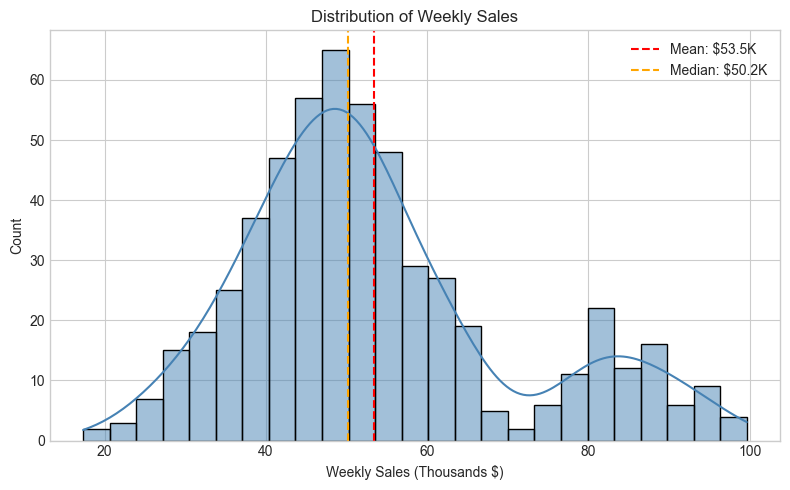

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(data=ff_ds, x='SalesInThousands', bins=25, kde=True, color='steelblue')
plt.axvline(ff_ds['SalesInThousands'].mean(), color='red', linestyle='--',
            label=f"Mean: ${ff_ds['SalesInThousands'].mean():.1f}K")
plt.axvline(ff_ds['SalesInThousands'].median(), color='orange', linestyle='--',
            label=f"Median: ${ff_ds['SalesInThousands'].median():.1f}K")
plt.xlabel('Weekly Sales (Thousands $)')
plt.ylabel('Count')
plt.title('Distribution of Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()

- Most stores sell between **$40K–$65K** per week.
- Slightly right-skewed — a few stores have very high sales.

#### Store Age vs Sales

Does an older store sell more?

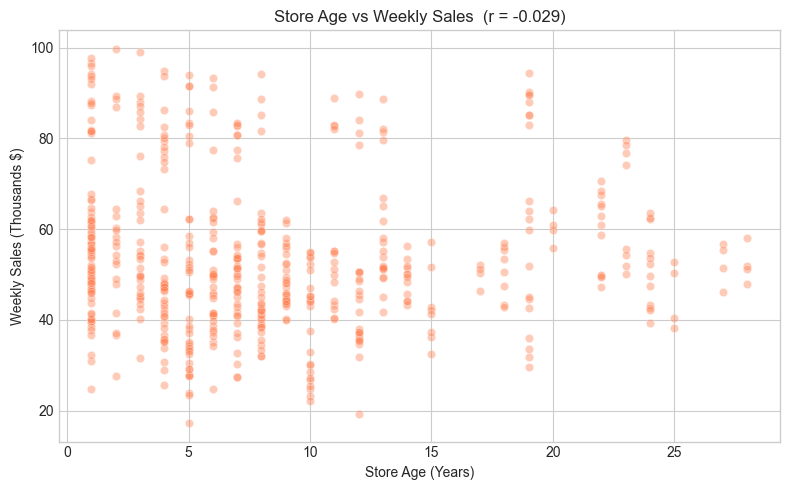

In [10]:
corr = ff_ds['AgeOfStore'].corr(ff_ds['SalesInThousands'])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=ff_ds, x='AgeOfStore', y='SalesInThousands', alpha=0.4, color='coral')
plt.xlabel('Store Age (Years)')
plt.ylabel('Weekly Sales (Thousands $)')
plt.title(f'Store Age vs Weekly Sales  (r = {corr:.3f})')
plt.tight_layout()
plt.show()

Very low correlation — store age does not affect sales.

#### Market Size

C:\Users\Shsha\AppData\Local\Temp\ipykernel_25672\2628451810.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ff_ds, x='MarketSize', order=market_order, ax=axes[0], palette='Set2')
C:\Users\Shsha\AppData\Local\Temp\ipykernel_25672\2628451810.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ff_ds, x='MarketSize', y='SalesInThousands',


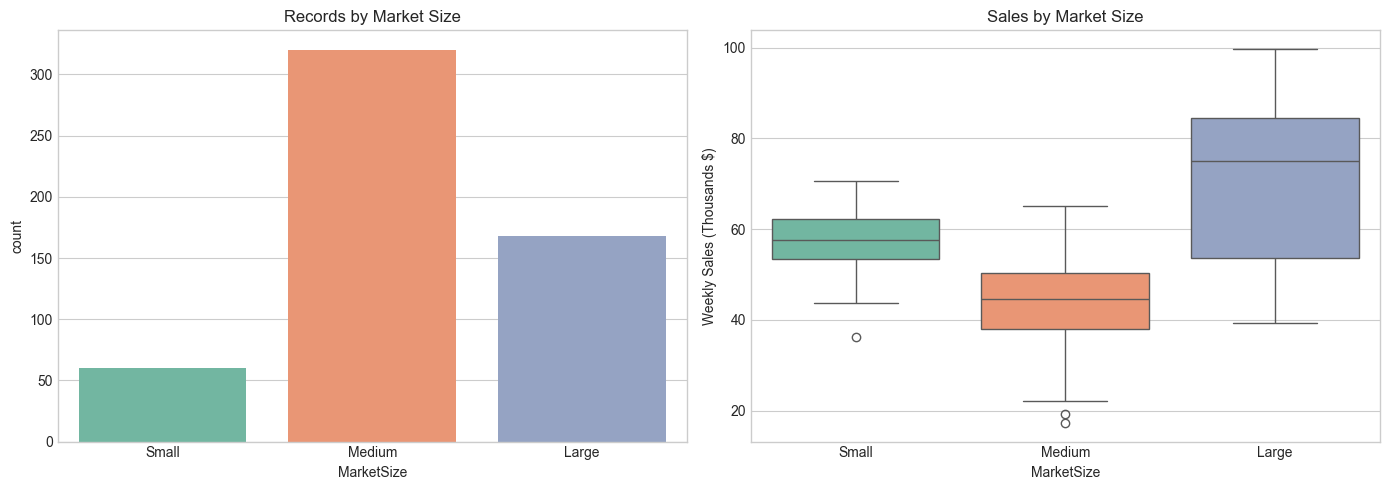

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
market_order = ['Small', 'Medium', 'Large']

sns.countplot(data=ff_ds, x='MarketSize', order=market_order, ax=axes[0], palette='Set2')
axes[0].set_title('Records by Market Size')

sns.boxplot(data=ff_ds, x='MarketSize', y='SalesInThousands',
            order=market_order, ax=axes[1], palette='Set2')
axes[1].set_title('Sales by Market Size')
axes[1].set_ylabel('Weekly Sales (Thousands $)')

plt.tight_layout()
plt.show()

- Larger markets have higher sales — expected.
- All 3 promotions are spread equally across market sizes, so this won't affect our comparison.

### 5.2 Sales vs Other Variables

#### Sales by Promotion — the main comparison

In [12]:
# إحصائيات المبيعات لكل حملة ترويجية
promotion_summary = ff_ds.groupby('Promotion')['SalesInThousands'].agg(
    Mean='mean',
    Median='median',
    Std='std',
    Count='count'
).round(2)
promotion_summary.index = [f'Promotion {p}' for p in promotion_summary.index]

print("Sales Summary by Promotion (in $K):")
print(promotion_summary.to_string())

Sales Summary by Promotion (in $K):
              Mean  Median    Std  Count
Promotion 1  58.10   55.39  16.55    172
Promotion 2  47.33   45.39  15.11    188
Promotion 3  55.36   51.16  16.77    188


C:\Users\Shsha\AppData\Local\Temp\ipykernel_25672\4189285859.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ff_ds, x='Promotion', y='SalesInThousands', palette='Set2')


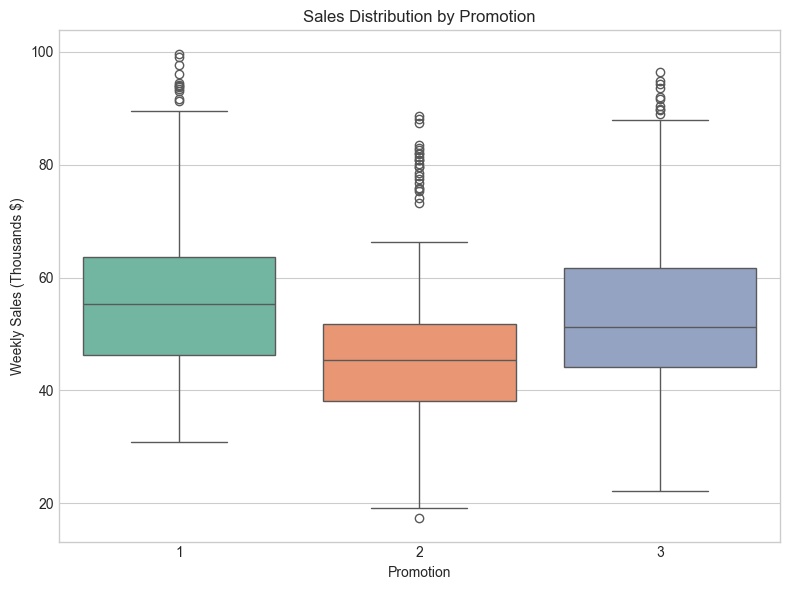

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=ff_ds, x='Promotion', y='SalesInThousands', palette='Set2')
plt.xlabel('Promotion')
plt.ylabel('Weekly Sales (Thousands $)')
plt.title('Sales Distribution by Promotion')
plt.tight_layout()
plt.show()

- **Promotion 1** has the highest mean (~$58.1K), then Promotion 3 (~$55.4K), then Promotion 2 (~$47.3K).
- The boxes overlap, so we need a statistical test to confirm.

#### Sales Over the 4 Weeks

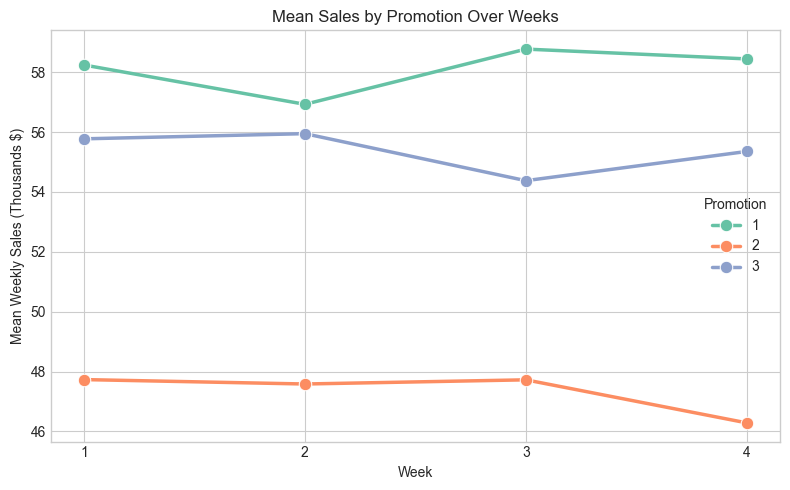

In [14]:
weekly_avg = ff_ds.groupby(['week', 'Promotion'])['SalesInThousands'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=weekly_avg, x='week', y='SalesInThousands', hue='Promotion',
             marker='o', palette='Set2', linewidth=2.5, markersize=9)
plt.xlabel('Week')
plt.ylabel('Mean Weekly Sales (Thousands $)')
plt.title('Mean Sales by Promotion Over Weeks')
plt.xticks([1, 2, 3, 4])
plt.tight_layout()
plt.show()

- Promotion 1 leads every week.
- No clear upward or downward trend — results are stable.

## 6. Hypothesis Testing

Is the difference between promotions real, or just random?

- **H₀:** All promotions have equal mean sales (μ₁ = μ₂ = μ₃)
- **H₁:** At least one promotion is different

### 6.1 One-Way ANOVA

Tests whether mean sales are the same across all 3 promotions.
- **p < 0.05** → reject H₀ → at least one promotion is different

In [15]:
groups = [
    ff_ds[ff_ds['Promotion'] == p]['SalesInThousands']
    for p in sorted(ff_ds['Promotion'].unique())
]

f_stat, p_value = f_oneway(*groups)

print("One-Way ANOVA Results (alpha = 0.05)")
print("=" * 45)
print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("REJECT H0: At least one promotion is significantly different.")
else:
    print("FAIL TO REJECT H0: No significant difference between promotions.")

One-Way ANOVA Results (alpha = 0.05)
F-statistic : 21.9535
p-value     : 0.000000

REJECT H0: At least one promotion is significantly different.


p ≈ 0.000 → we **reject H₀** → the difference between promotions is real and not due to chance.

## 7. Summary

### Findings

1. **Promotion 1 has the highest sales** — ~$58.1K/week, vs $55.4K (P3) and $47.3K (P2).
2. **The difference is statistically significant** — confirmed by One-Way ANOVA.
3. **Sales were stable across all 4 weeks** — no time trend.

### Recommendation

> **Use Promotion 1** for the new product launch.

### Limitations

- Store-level factors (location, foot traffic) were not controlled.
- 4 weeks may not capture seasonal effects.
- Campaign cost was not considered — only sales.